In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

from pca import pca
import matplotlib.pyplot as plt

In [2]:
milk = pd.read_csv(r"D:\Machine_Learning_CDAC-AI\a] Datasets\milk.csv", index_col=0)
print(milk.shape)

(25, 5)


In [3]:
print(milk.dtypes)

water      float64
protein    float64
fat        float64
lactose    float64
ash        float64
dtype: object


In [4]:
# Convert column names to strings
milk.columns = milk.columns.astype(str)

# Convert all data columns to numeric, forcing errors to NaN 
milk_numeric = milk.apply(pd.to_numeric, errors='coerce')

# Drop columns that are completely non-numeric (like text labels) or have all NaNs
milk_numeric = milk_numeric.dropna(axis=1, how='all')

# Fill any stray NaNs in your remaining numeric columns if necessary, 
milk_numeric = milk_numeric.dropna()

# Now run your scaling code
scaler = StandardScaler().set_output(transform='pandas')
milk_scaled = scaler.fit_transform(milk_numeric)

print("Successfully scaled! New Shape:", milk_scaled.shape)

Successfully scaled! New Shape: (25, 5)


In [5]:
prcomp = PCA().set_output(transform='pandas')
pc_data = prcomp.fit_transform(milk_scaled)
pc_data.var()   #PC0 > PC1 > .....> PC4

pca0    4.040412
pca1    0.924372
pca2    0.134291
pca3    0.102689
pca4    0.006570
dtype: float64

In [6]:
pc_data

,pca0,pca1,pca2,pca3,pca4
Animal,,,,,
HORSE,2.435175,-0.231478,0.330150,0.307664,0.048184
ORANGUTAN,2.258736,-0.693148,0.029035,-0.081057,-0.000532
MONKEY,2.335861,-0.663328,0.101257,0.247997,0.010109
DONKEY,2.318677,-0.273815,0.109881,-0.092873,-0.006769
HIPPO,2.060294,-1.019199,-0.762436,-0.510091,0.029382
CAMEL,1.301536,0.137303,-0.198742,-0.282160,-0.014668
BISON,1.282742,0.622667,0.253785,0.065148,-0.044486
BUFFALO,0.505068,0.088235,0.008383,0.133774,0.083806
GUINEA PIG,-0.255502,0.287373,-0.881857,-0.013100,-0.016484


In [7]:
values, vectors = np.linalg.eig(milk_scaled.cov())
print("Eigen Values: ",values)

Eigen Values:  [4.0404117  0.92437238 0.00656977 0.13429088 0.1026886 ]


In [8]:
vectors

array([[-0.47294379,  0.35285509, -0.70967042,  0.36921298,  0.10893632],
       [ 0.46657047,  0.32094099, -0.1930657 ,  0.15196177, -0.78672876],
       [ 0.44868269, -0.47603724, -0.66831106, -0.30699163,  0.17660367],
       [-0.48289116,  0.05951482, -0.11159049, -0.77642589, -0.38468756],
       [ 0.35232959,  0.73643513,  0.00118661, -0.378825  ,  0.43590982]])

In [9]:
milk.columns

Index(['water', 'protein', 'fat', 'lactose', 'ash'], dtype='object')

### Matrix of Eigen Vectors

In [10]:
prcomp.components_

array([[ 0.47294379, -0.46657047, -0.44868269,  0.48289116, -0.35232959],
       [ 0.35285509,  0.32094099, -0.47603724,  0.05951482,  0.73643513],
       [-0.36921298, -0.15196177,  0.30699163,  0.77642589,  0.378825  ],
       [-0.10893632,  0.78672876, -0.17660367,  0.38468756, -0.43590982],
       [ 0.70967042,  0.1930657 ,  0.66831106,  0.11159049, -0.00118661]])

### Variation Explained

In [11]:
prcomp.explained_variance_

array([4.0404117 , 0.92437238, 0.13429088, 0.1026886 , 0.00656977])

### Proportions of Variations Explained

In [12]:
prcomp.explained_variance_ / np.sum(prcomp.explained_variance_)

array([0.77575905, 0.1774795 , 0.02578385, 0.01971621, 0.0012614 ])

In [13]:
prcomp.explained_variance_ratio_

array([0.77575905, 0.1774795 , 0.02578385, 0.01971621, 0.0012614 ])

### % Variation

In [14]:
prcomp.explained_variance_ratio_*100

array([77.57590469, 17.74794969,  2.57838496,  1.97162103,  0.12613963])

In [15]:
np.cumsum(prcomp.explained_variance_ratio_*100)

array([ 77.57590469,  95.32385438,  97.90223934,  99.87386037,
       100.        ])

[27-06-2026 15:58:10] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 5 columns of the input data.
[27-06-2026 15:58:10] [pca.pca] [INFO] Fit using PCA.
[27-06-2026 15:58:10] [pca.pca] [INFO] Compute loadings and PCs.
[27-06-2026 15:58:10] [pca.pca] [INFO] Compute explained variance.
[27-06-2026 15:58:10] [pca.pca] [INFO] The top 2 principal component(s) explains >= 95.00% of the explained variance.
[27-06-2026 15:58:10] [pca.pca] [INFO] The PCA reduction is performed on 5 variables (columns) of the input dataframe.
[27-06-2026 15:58:10] [pca.pca] [INFO] Fit using PCA.
[27-06-2026 15:58:10] [pca.pca] [INFO] Compute loadings and PCs.
[27-06-2026 15:58:10] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[2]
[27-06-2026 15:58:10] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[27-06-2026 15:58:10] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[27

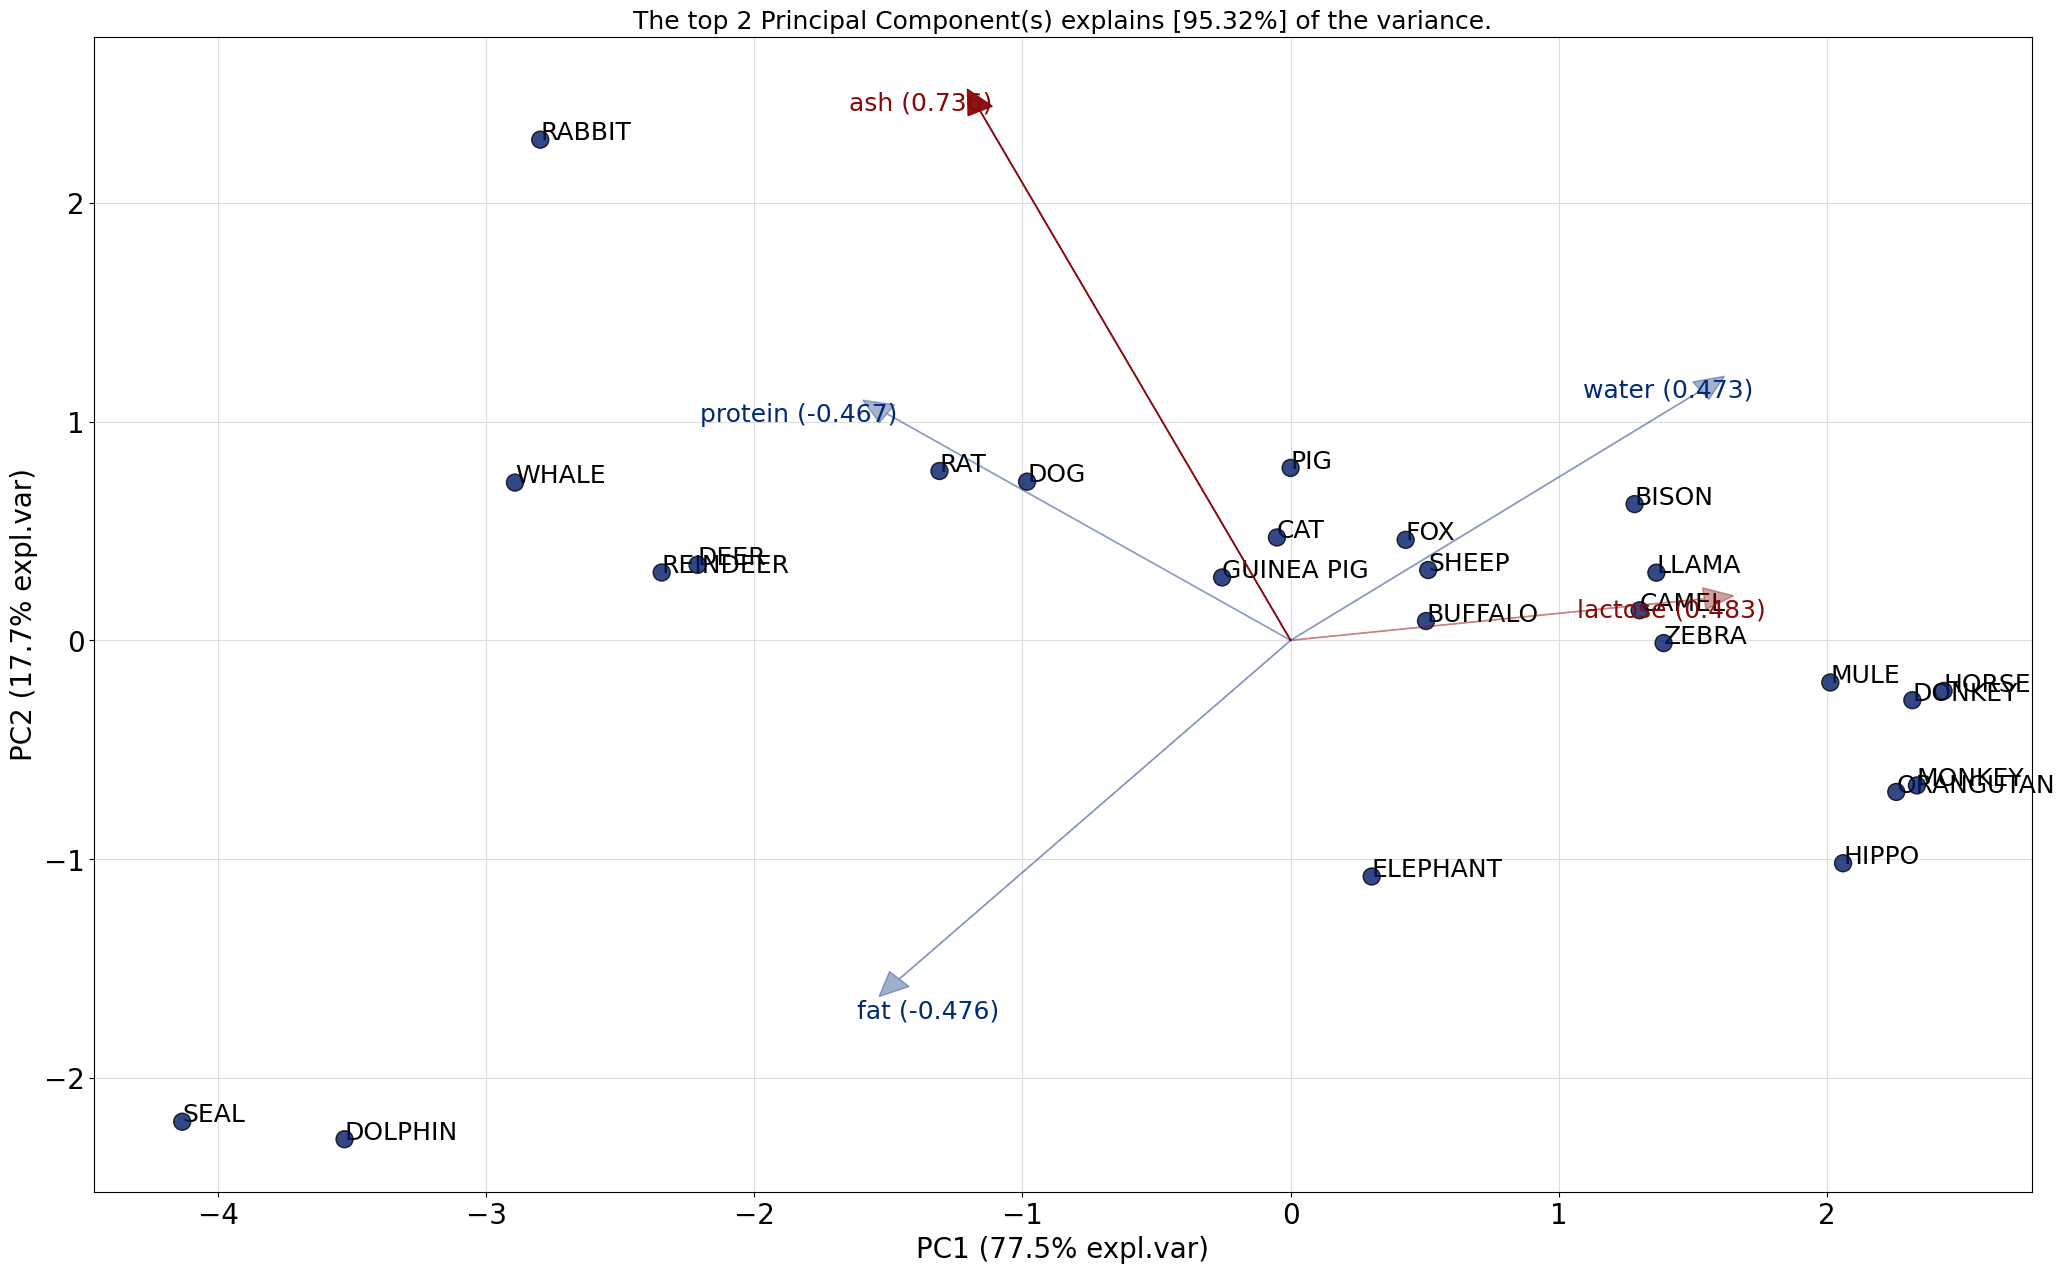

In [16]:
model = pca()
results = model.fit_transform(milk_scaled,
                             col_labels = milk_numeric.columns,  # Cleaned column names
                             row_labels = list(milk_numeric.index)) # Cleaned row labels
model.biplot(legend=True)

for i in np.arange(0, pc_data.shape[0]):
    plt.text(pc_data.values[i, 0],
             pc_data.values[i, 1],
             str(pc_data.index[i]))

plt.show()

In [17]:
milk

,water,protein,fat,lactose,ash
Animal,,,,,
HORSE,90.1,2.6,1.0,6.9,0.35
ORANGUTAN,88.5,1.4,3.5,6.0,0.24
MONKEY,88.4,2.2,2.7,6.4,0.18
DONKEY,90.3,1.7,1.4,6.2,0.40
HIPPO,90.4,0.6,4.5,4.4,0.10
CAMEL,87.7,3.5,3.4,4.8,0.71
BISON,86.9,4.8,1.7,5.7,0.90
BUFFALO,82.1,5.9,7.9,4.7,0.78
GUINEA PIG,81.9,7.4,7.2,2.7,0.85
